In [1]:

import numpy as np
import pandas as pd
import csv
import matplotlib as mpl
import matplotlib.pyplot as plt
import pyhepmc
import itertools
import math

xmn = 938.5


# Line styles
mpl.rcParams['lines.linewidth'] = 1.5
mpl.rcParams['lines.antialiased'] = True
mpl.rcParams['lines.dashed_pattern'] = 2.8, 1.5
mpl.rcParams['lines.dashdot_pattern'] = 4.8, 1.5, 0.8, 1.5
mpl.rcParams['lines.dotted_pattern'] = 1.1, 1.1
mpl.rcParams['lines.scale_dashes'] = True

# Default colors
from cycler import cycler
mpl.rcParams['axes.prop_cycle'] = cycler('color',['cornflowerblue','forestgreen','maroon','goldenrod','firebrick','mediumorchid', 'navy', 'brown'])

# Fonts
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = 'CMU Serif'
mpl.rcParams['font.sans-serif'] = 'CMU Sans Serif, DejaVu Sans, Bitstream Vera Sans, Lucida Grande, Verdana, Geneva, Lucid, Arial, Helvetica, Avant Garde, sans-serif'
mpl.rcParams['text.usetex'] = True

# Axes
mpl.rcParams['axes.linewidth'] = 1.0
mpl.rcParams['axes.labelsize'] = 20
mpl.rcParams['axes.labelpad'] = 9.0
                                                  
                                                  
# Tick marks - the essence of life
mpl.rcParams['xtick.top'] = True
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.minor.size'] = 2.5
mpl.rcParams['xtick.major.width'] = 1.0
mpl.rcParams['xtick.minor.width'] = 0.75
mpl.rcParams['xtick.major.pad'] = 8
mpl.rcParams['xtick.labelsize'] = 20
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.right'] = True
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.minor.size'] = 2.5
mpl.rcParams['ytick.major.width'] = 1.0
mpl.rcParams['ytick.minor.width'] = 0.75
mpl.rcParams['ytick.major.pad'] = 8
mpl.rcParams['ytick.labelsize'] = 20
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['ytick.minor.visible'] = True

# Legend
mpl.rcParams['legend.fontsize'] = 20
mpl.rcParams['legend.frameon'] = True
mpl.rcParams['legend.framealpha'] = 1.
#mpl.rcParams['legend.edgecolor'] = 'black'
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['legend.borderpad'] = 0.4 # border whitespace
mpl.rcParams['legend.labelspacing'] = 0.5 # the vertical space between the legend entries
mpl.rcParams['legend.handlelength'] = 1.5 # the length of the legend lines
mpl.rcParams['legend.handleheight'] = 0.7 # the height of the legend handle
mpl.rcParams['legend.handletextpad'] = 0.5 # the space between the legend line and legend text
mpl.rcParams['legend.borderaxespad'] = 0.5 # the border between the axes and legend edge
mpl.rcParams['legend.columnspacing'] = 2.0 # column separation


# Figure size
mpl.rcParams['figure.figsize'] = 12, 6
mpl.rcParams['figure.dpi'] = 200

# Save details
mpl.rcParams['savefig.bbox'] = 'tight'
mpl.rcParams['savefig.pad_inches'] = 0.1

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern Roman']

def fix_ax(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.get_xaxis().tick_bottom()
    ax.get_yaxis().tick_left()
    
    return ax

In [55]:
def classify_isospin(isop1,isop2):
    if(isop1 == 2212 and isop2 == 2212):
        return 'pp'
    elif(isop1 == 2112 and isop2 == 2112):
        return 'nn'
    else:
        return 'np'

def get_double_diff_xsec_wgt(file, angle, delta, mybins_omega):

    emin = 2*np.sqrt(225**2 + 938**2)

    mn = 938.5

    mybins2 = np.linspace(-1.,1.,len(mybins_omega))
    mybins_leadingmom = np.linspace(225.,1500.,len(mybins_omega))
    mybins_totalE = np.linspace(emin,3000,len(mybins_omega))
    momentum_bins = np.linspace(225,1200,30)
    emiss_bins = np.linspace(0,300,60)
    init_momentum_bins = np.linspace(0,600,16)
    init_momentum_bins_more = np.linspace(0,600,30)
    Q2_bins = np.linspace(0,1.4,30)
    EQE_bins = np.linspace(0.4,1.4,30)
    
    omega_nn = np.zeros(len(mybins_omega)-1)
    omega_np = np.zeros(len(mybins_omega)-1)
    omega_pp = np.zeros(len(mybins_omega)-1)
    omega_nuc = np.zeros(len(mybins_omega)-1)
    Q2_nuc = np.zeros(len(Q2_bins)-1)
    EQE_nuc = np.zeros(len(e4v_EQE_bins)-1)

    leading_nmom_nn = np.zeros(len(mybins_leadingmom)-1)
    leading_nmom_np = np.zeros(len(mybins_leadingmom)-1)
    leading_mom_hist = np.zeros(len(mybins_leadingmom)-1)
    leading_submom_hist = np.zeros(len(mybins_leadingmom)-1)
    leading_mom_re_hist = np.zeros(len(mybins_leadingmom)-1)
    leading_submom_re_hist = np.zeros(len(mybins_leadingmom)-1)

    leading_init_mom_nn = np.zeros(len(init_momentum_bins_more)-1)
    leading_init_mom_np = np.zeros(len(init_momentum_bins_more)-1)
    subleading_init_mom_nn = np.zeros(len(init_momentum_bins_more)-1)
    subleading_init_mom_np = np.zeros(len(init_momentum_bins_more)-1)
    
    cos12_nn = np.zeros(len(mybins2)-1)
    cos12_np = np.zeros(len(mybins2)-1) 
    cos12 = np.zeros(len(mybins2)-1) 

    cospp1_hist = np.zeros(len(mybins2)-1)
    cospp2_hist = np.zeros(len(mybins2)-1)

    E_total_nn = np.zeros(len(mybins_totalE) -1)
    E_total_np = np.zeros(len(mybins_totalE) -1)

    np_momentum = np.zeros((len(momentum_bins)-1,len(momentum_bins)-1))
    nn_momentum = np.zeros((len(momentum_bins)-1,len(momentum_bins)-1))

    np_init_momentum = np.zeros((len(init_momentum_bins)-1,len(init_momentum_bins)-1))
    nn_init_momentum = np.zeros((len(init_momentum_bins)-1,len(init_momentum_bins)-1))

    Emiss_np = np.zeros((len(emiss_bins)-1))
    Emiss_nn = np.zeros((len(emiss_bins)-1))
    Emiss = np.zeros(len(emiss_bins)-1)

    
    ebind = 21.0
    
    xsec = 0
    sum_of_weights = 0

    num_nn = 0
    num_np = 0
    num_pp = 0
    other = 0
    total = 0

    high_cos = math.cos((angle + delta)*np.pi/180)
    low_cos = math.cos((angle - delta)*np.pi/180)
    delta_cos = (low_cos - high_cos)
    with open(file, 'r') as f:
        xsec = float(f.readline().strip())
        while True:
            block = list(itertools.islice(f,7))
            if not block:
                break
            probe = [float(x) for x in block[0].split()]
            lep = [float(x) for x in block[1].split()]
            nuc1 = [float(x) for x in block[2].split()]
            nucp1 = [float(x) for x in block[3].split()]
            nuc2 = [float(x) for x in block[4].split()]
            nucp2 = [float(x) for x in block[5].split()]
            wgt = float(block[6])

            isospin = classify_isospin(nuc1[4],nuc2[4])

            omega = probe[0] - lep[0]   
            probe_3 = [probe[1], probe[2], probe[3]]
            probe_mom = np.sqrt(np.dot(probe_3,probe_3))
            lep_3 = [lep[1], lep[2], lep[3]]
            lep_p = np.sqrt(np.dot(lep_3,lep_3))
            
            qvec = np.array(probe_3) - np.array(lep_3)
            qvecmag = np.sqrt(np.dot(qvec,qvec))

            q4 = [omega-40.,qvec[0],qvec[1],qvec[2]]

            Q2 = qvecmag**2 - omega**2

            Q2 *= 1e-6
            wgt *= Q2**2
            total+=1
            sum_of_weights += wgt/Q2**2
            
            if(lep[0] < 400.):
                continue

            costhetal = np.dot(probe_3,lep_3)/lep[0]/probe[0]

            thetal = np.arccos(costhetal)*180/np.pi

            #if (thetal < 17. or thetal > 45.):
            #    continue


            #if( thetal < 36.5 or thetal > 38.5):
            #    continue
            
            if (thetal < 17. + 7./(lep_p/1000.) or thetal > 45.):
                continue

            nuc1_3 = [nuc1[1],nuc1[2],nuc1[3]]
            nuc2_3 = [nuc2[1],nuc2[2],nuc2[3]]
            nucp1_3 = [nucp1[1],nucp1[2],nucp1[3]]
            nucp2_3 = [nucp2[1],nucp2[2],nucp2[3]]
            
            nuc1_mom = np.sqrt(np.dot(nuc1_3,nuc1_3))
            nuc2_mom = np.sqrt(np.dot(nuc2_3,nuc2_3))
            nucp1_mom = np.sqrt(np.dot(nucp1_3,nucp1_3))
            nucp2_mom = np.sqrt(np.dot(nucp2_3,nucp2_3))

            angle_between = np.dot(nucp1_3,nucp2_3)/nucp1_mom/nucp2_mom

            leading_mom = 0.
            subleading_mom = 0.
            
            totalE = nucp1[0] + nucp2[0]
            if(nucp1_mom > nucp2_mom):
                leading_mom = nucp1_mom
                subleading_mom = nucp2_mom
            else:
                leading_mom = nucp2_mom
                subleading_mom = nucp1_mom

            cospp1 = nucp1_3[2]/nucp1_mom
            cospp2 = nucp2_3[2]/nucp2_mom

            pp12cos = np.dot(nucp1_3,nucp2_3)/(nucp1_mom*nucp2_mom)

            EQE = (2.*mn*ebind + 2*mn*lep[0])/2./(mn - lep[0] + lep[0]*costhetal)/1e3


            Em = 0
            if(nucp1[4] == 2212 and nucp2[4] == 2112):
                T1 = np.sqrt(mn**2 + nucp1_mom**2) - mn
                Em = omega - T1
            elif(nucp1[4] == 2112 and nucp2[4] == 2212):
                T2 = np.sqrt(mn**2 + nucp2_mom**2) - mn
                Em = omega - T2
            elif(nucp1[4] == 2212 and nucp2[4] == 2112):
                T2 = np.sqrt(mn**2 + nucp2_mom**2) - mn
                Em = omega - T2
            elif(nucp1[4] == 2212 and nucp2[4] == 2212):
                T1 = np.sqrt(mn**2 + nucp1_mom**2) - mn
                Em = omega - T1
            #else:
            #    continue

            #idx0 = np.searchsorted(mybins_omega, omega, side='left')
            #if idx0 > len(mybins_omega)-1:
            #    continue
            idx0=2
            #idxmom = np.searchsorted(mybins_leadingmom,leading_mom,side='left')
            #if idxmom > len(mybins_leadingmom) -1:
            #    continue
                
            #idxsubmom = np.searchsorted(mybins_leadingmom,subleading_mom,side='left')
            #if idxsubmom > len(mybins_omega) -1:
            #    continue

            #idxcos = np.searchsorted(mybins2,cospp1,side='left')
            #if idxcos > len(mybins2) -1:
            #    continue
            #idxcos2 = np.searchsorted(mybins2,cospp2,side='left')
            #if idxcos2 > len(mybins2) -1:
            #    continue
            #idxem = np.searchsorted(emiss_bins,Em, side='left')
            #if idxem > len(emiss_bins) -1:
            #    continue

            #idxQ2 = np.searchsorted(Q2_bins, Q2, side='left')
            #if idxQ2 > len(Q2_bins) -1:
            #    continue

            idxEQE = np.searchsorted(e4v_EQE_bins, EQE, side='left')
            if idxEQE > len(e4v_EQE_bins) - 1:
                continue

            #idx12 = np.searchsorted(mybins2,angle_between,side='left')
            #if idx12 > len(mybins2) -1:
            #    continue
                
            #Q2_nuc[idxQ2-1] += wgt

            EQE_nuc[idxEQE-1] += wgt

            #cos12[idx12-1] += wgt
                
            #Emiss[idxem-1] += wgt
            #cospp1_hist[idxcos-1] += wgt
            #cospp2_hist[idxcos2-1] += wgt
            omega_nuc[idx0-1] += wgt 
            #leading_mom_hist[idxmom-1] += wgt
            #leading_submom_hist[idxsubmom-1] += wgt

            #if(isospin == 'pp'):
            #    omega_nn[idx0-1] += wgt
            #    Emiss_nn[idxem-1] += wgt
            #if(isospin == 'np' and nucp1[4] == 2212):
            #    omega_np[idx0-1] += wgt
            #    Emiss_np[idxem-1] += wgt

        dcos = np.cos(36.5*np.pi/180.) - np.cos(38.5*np.pi/180.)
            
        omega_bin_width = 2*np.pi*np.diff(mybins_omega)*dcos
        omega_nuc *= xsec/omega_bin_width/sum_of_weights
        omega_nn *= xsec/omega_bin_width/sum_of_weights
        omega_np *= xsec/omega_bin_width/sum_of_weights
        leading_mom_hist *= xsec/np.diff(mybins_leadingmom)/sum_of_weights
        leading_submom_hist *= xsec/np.diff(mybins_leadingmom)/sum_of_weights
        cospp1_hist *= xsec/np.diff(mybins2)/sum_of_weights
        cospp2_hist *= xsec/np.diff(mybins2)/sum_of_weights
        Emiss_nn *= xsec/np.diff(emiss_bins)/sum_of_weights
        Emiss_np *= xsec/np.diff(emiss_bins)/sum_of_weights

        EQE_nuc *= xsec/np.diff(e4v_EQE_bins)/sum_of_weights

        Q2_nuc *= xsec/np.diff(Q2_bins)/sum_of_weights

        cos12 *= xsec/np.diff(mybins2)/sum_of_weights
    
    print('xsec = ',xsec)
    return omega_nuc,cos12,Q2_nuc,leading_mom_hist,leading_submom_hist,cospp1_hist,cospp2_hist,Emiss_nn,Emiss_np,EQE_nuc 
def get_double_diff_xsec_wgt_re(file, angle, delta, mybins_omega):

    emin = 2*np.sqrt(225**2 + 938**2)

    mn = 938.5

    mybins2 = np.linspace(-1.,1.,len(mybins_omega))
    mybins_leadingmom = np.linspace(225.,1500.,len(mybins_omega))
    mybins_totalE = np.linspace(emin,3000,len(mybins_omega))
    momentum_bins = np.linspace(225,1200,30)
    emiss_bins = np.linspace(0,300,60)
    init_momentum_bins = np.linspace(0,600,16)
    init_momentum_bins_more = np.linspace(0,600,30)
    Q2_bins = np.linspace(0,1.4,30)
    EQE_bins = np.linspace(0.4,1.4,30)
    EQE_bins_resampled = np.linspace(0.4,1.4,30)
    
    omega_nn = np.zeros(len(mybins_omega)-1)
    omega_np = np.zeros(len(mybins_omega)-1)
    omega_pp = np.zeros(len(mybins_omega)-1)
    omega_nuc = np.zeros(len(mybins_omega)-1)
    Q2_nuc = np.zeros(len(Q2_bins)-1)
    EQE_nuc = np.zeros(len(EQE_bins)-1)

    leading_nmom_nn = np.zeros(len(mybins_leadingmom)-1)
    leading_nmom_np = np.zeros(len(mybins_leadingmom)-1)
    leading_mom_hist = np.zeros(len(mybins_leadingmom)-1)
    leading_submom_hist = np.zeros(len(mybins_leadingmom)-1)
    leading_mom_re_hist = np.zeros(len(mybins_leadingmom)-1)
    leading_submom_re_hist = np.zeros(len(mybins_leadingmom)-1)

    leading_init_mom_nn = np.zeros(len(init_momentum_bins_more)-1)
    leading_init_mom_np = np.zeros(len(init_momentum_bins_more)-1)
    subleading_init_mom_nn = np.zeros(len(init_momentum_bins_more)-1)
    subleading_init_mom_np = np.zeros(len(init_momentum_bins_more)-1)
    
    cos12_nn = np.zeros(len(mybins2)-1)
    cos12_np = np.zeros(len(mybins2)-1) 
    cos12 = np.zeros(len(mybins2)-1) 

    cospp1_hist = np.zeros(len(mybins2)-1)
    cospp2_hist = np.zeros(len(mybins2)-1)

    E_total_nn = np.zeros(len(mybins_totalE) -1)
    E_total_np = np.zeros(len(mybins_totalE) -1)

    np_momentum = np.zeros((len(momentum_bins)-1,len(momentum_bins)-1))
    nn_momentum = np.zeros((len(momentum_bins)-1,len(momentum_bins)-1))

    np_init_momentum = np.zeros((len(init_momentum_bins)-1,len(init_momentum_bins)-1))
    nn_init_momentum = np.zeros((len(init_momentum_bins)-1,len(init_momentum_bins)-1))

    Emiss_np = np.zeros((len(emiss_bins)-1))
    Emiss_nn = np.zeros((len(emiss_bins)-1))
    Emiss = np.zeros(len(emiss_bins)-1)

    
    ebind = 21.0
    
    xsec = 0
    sum_of_weights = 0

    num_nn = 0
    num_np = 0
    num_pp = 0
    other = 0
    total = 0

    high_cos = math.cos((angle + delta)*np.pi/180)
    low_cos = math.cos((angle - delta)*np.pi/180)
    delta_cos = (low_cos - high_cos)
    with open(file, 'r') as f:
        xsec = float(f.readline().strip())
        while True:
            block = list(itertools.islice(f,7))
            if not block:
                break
            probe = [float(x) for x in block[0].split()]
            lep = [float(x) for x in block[1].split()]
            nuc1 = [float(x) for x in block[2].split()]
            nucp1 = [float(x) for x in block[3].split()]
            nuc2 = [float(x) for x in block[4].split()]
            nucp2 = [float(x) for x in block[5].split()]
            wgt = float(block[6])

            isospin = classify_isospin(nuc1[4],nuc2[4])

            omega = probe[0] - lep[0]   
            probe_3 = [probe[1], probe[2], probe[3]]
            probe_mom = np.sqrt(np.dot(probe_3,probe_3))
            lep_3 = [lep[1], lep[2], lep[3]]
            lep_p = np.sqrt(np.dot(lep_3,lep_3))
            
            qvec = np.array(probe_3) - np.array(lep_3)
            qvecmag = np.sqrt(np.dot(qvec,qvec))

            q4 = [omega-40.,qvec[0],qvec[1],qvec[2]]

            Q2 = qvecmag**2 - omega**2

            Q2 *= 1e-6
            wgt *= Q2**2
            total+=1
            sum_of_weights += wgt/Q2**2
            
            if(lep[0] < 400.):
                continue

            costhetal = np.dot(probe_3,lep_3)/lep[0]/probe[0]

            thetal = np.arccos(costhetal)*180/np.pi

            #if (thetal < 17. or thetal > 45.):
            #    continue

            if (thetal < 17. + 7./(lep_p/1000.) or thetal > 45.):
                continue

            nuc1_3 = [nuc1[1],nuc1[2],nuc1[3]]
            nuc2_3 = [nuc2[1],nuc2[2],nuc2[3]]
            nucp1_3 = [nucp1[1],nucp1[2],nucp1[3]]
            nucp2_3 = [nucp2[1],nucp2[2],nucp2[3]]

            pp1_re,pp2_re = resample_2nuc(q4,225.0)
            #break

            nucp1_3 = pp1_re[1:4]
            nucp2_3 = pp2_re[1:4]

            nuc1_mom = np.sqrt(np.dot(nuc1_3,nuc1_3))
            nuc2_mom = np.sqrt(np.dot(nuc2_3,nuc2_3))
            nucp1_mom = np.sqrt(np.dot(nucp1_3,nucp1_3))
            nucp2_mom = np.sqrt(np.dot(nucp2_3,nucp2_3))

            angle_between = np.dot(nucp1_3,nucp2_3)/nucp1_mom/nucp2_mom

            leading_mom = 0.
            subleading_mom = 0.
            
            totalE = nucp1[0] + nucp2[0]
            if(nucp1_mom > nucp2_mom):
                leading_mom = nucp1_mom
                subleading_mom = nucp2_mom
            else:
                leading_mom = nucp2_mom
                subleading_mom = nucp1_mom

            cospp1 = nucp1_3[2]/nucp1_mom
            cospp2 = nucp2_3[2]/nucp2_mom

            pp12cos = np.dot(nucp1_3,nucp2_3)/(nucp1_mom*nucp2_mom)

            EQE = (2.*mn*ebind + 2*mn*lep[0])/2./(mn - lep[0] + lep[0]*costhetal)/1e3

            
            Em = 0
            if(nucp1[4] == 2212 and nucp2[4] == 2112):
                T1 = np.sqrt(mn**2 + nucp1_mom**2) - mn
                Em = omega - T1
            elif(nucp1[4] == 2112 and nucp2[4] == 2212):
                T2 = np.sqrt(mn**2 + nucp2_mom**2) - mn
                Em = omega - T2
            elif(nucp1[4] == 2212 and nucp2[4] == 2112):
                T2 = np.sqrt(mn**2 + nucp2_mom**2) - mn
                Em = omega - T2
            elif(nucp1[4] == 2212 and nucp2[4] == 2212):
                T1 = np.sqrt(mn**2 + nucp1_mom**2) - mn
                Em = omega - T1
            #else:
            #    continue

            #idx0 = np.searchsorted(mybins_omega, omega, side='left')
            #if idx0 > len(mybins_omega)-1:
            #    continue

            idxmom = np.searchsorted(mybins_leadingmom,leading_mom,side='left')
            if idxmom > len(mybins_leadingmom) -1:
                continue
                
            idxsubmom = np.searchsorted(mybins_leadingmom,subleading_mom,side='left')
            if idxsubmom > len(mybins_omega) -1:
                continue

            idxcos = np.searchsorted(mybins2,cospp1,side='left')
            if idxcos > len(mybins2) -1:
                continue
            idxcos2 = np.searchsorted(mybins2,cospp2,side='left')
            if idxcos2 > len(mybins2) -1:
                continue
            idxem = np.searchsorted(emiss_bins,Em, side='left')
            if idxem > len(emiss_bins) -1:
                continue

            #idxQ2 = np.searchsorted(Q2_bins, Q2, side='left')
            #if idxQ2 > len(Q2_bins) -1:
            #    continue

            idxEQE = np.searchsorted(EQE_bins, EQE, side='left')
            if idxEQE > len(EQE_bins) - 1:
                continue

            idx12 = np.searchsorted(mybins2,angle_between,side='left')
            if idx12 > len(mybins2) -1:
                continue
                
            #Q2_nuc[idxQ2-1] += wgt

            EQE_nuc[idxEQE-1] += wgt

            cos12[idx12-1] += wgt
                
            Emiss[idxem-1] += wgt
            cospp1_hist[idxcos-1] += wgt
            cospp2_hist[idxcos2-1] += wgt
            #omega_nuc[idx0-1] += wgt 
            leading_mom_hist[idxmom-1] += wgt
            leading_submom_hist[idxsubmom-1] += wgt

            #if(isospin == 'pp'):
            #    omega_nn[idx0-1] += wgt
            #    Emiss_nn[idxem-1] += wgt
            #if(isospin == 'np' and nucp1[4] == 2212):
            #    omega_np[idx0-1] += wgt
            #    Emiss_np[idxem-1] += wgt

            
        omega_bin_width = 2*np.pi*np.diff(mybins_omega)
        omega_nuc *= xsec/omega_bin_width/sum_of_weights
        omega_nn *= xsec/omega_bin_width/sum_of_weights
        omega_np *= xsec/omega_bin_width/sum_of_weights
        leading_mom_hist *= xsec/np.diff(mybins_leadingmom)/sum_of_weights
        leading_submom_hist *= xsec/np.diff(mybins_leadingmom)/sum_of_weights
        cospp1_hist *= xsec/np.diff(mybins2)/sum_of_weights
        cospp2_hist *= xsec/np.diff(mybins2)/sum_of_weights
        Emiss_nn *= xsec/np.diff(emiss_bins)/sum_of_weights
        Emiss_np *= xsec/np.diff(emiss_bins)/sum_of_weights

        EQE_nuc *= xsec/np.diff(EQE_bins)/sum_of_weights

        Q2_nuc *= xsec/np.diff(Q2_bins)/sum_of_weights

        cos12 *= xsec/np.diff(mybins2)/sum_of_weights
    
    print('xsec = ',xsec)
    return omega_nuc,cos12,Q2_nuc,leading_mom_hist,leading_submom_hist,cospp1_hist,cospp2_hist,Emiss_nn,Emiss_np,EQE_nuc   

xsec =  1605468.0


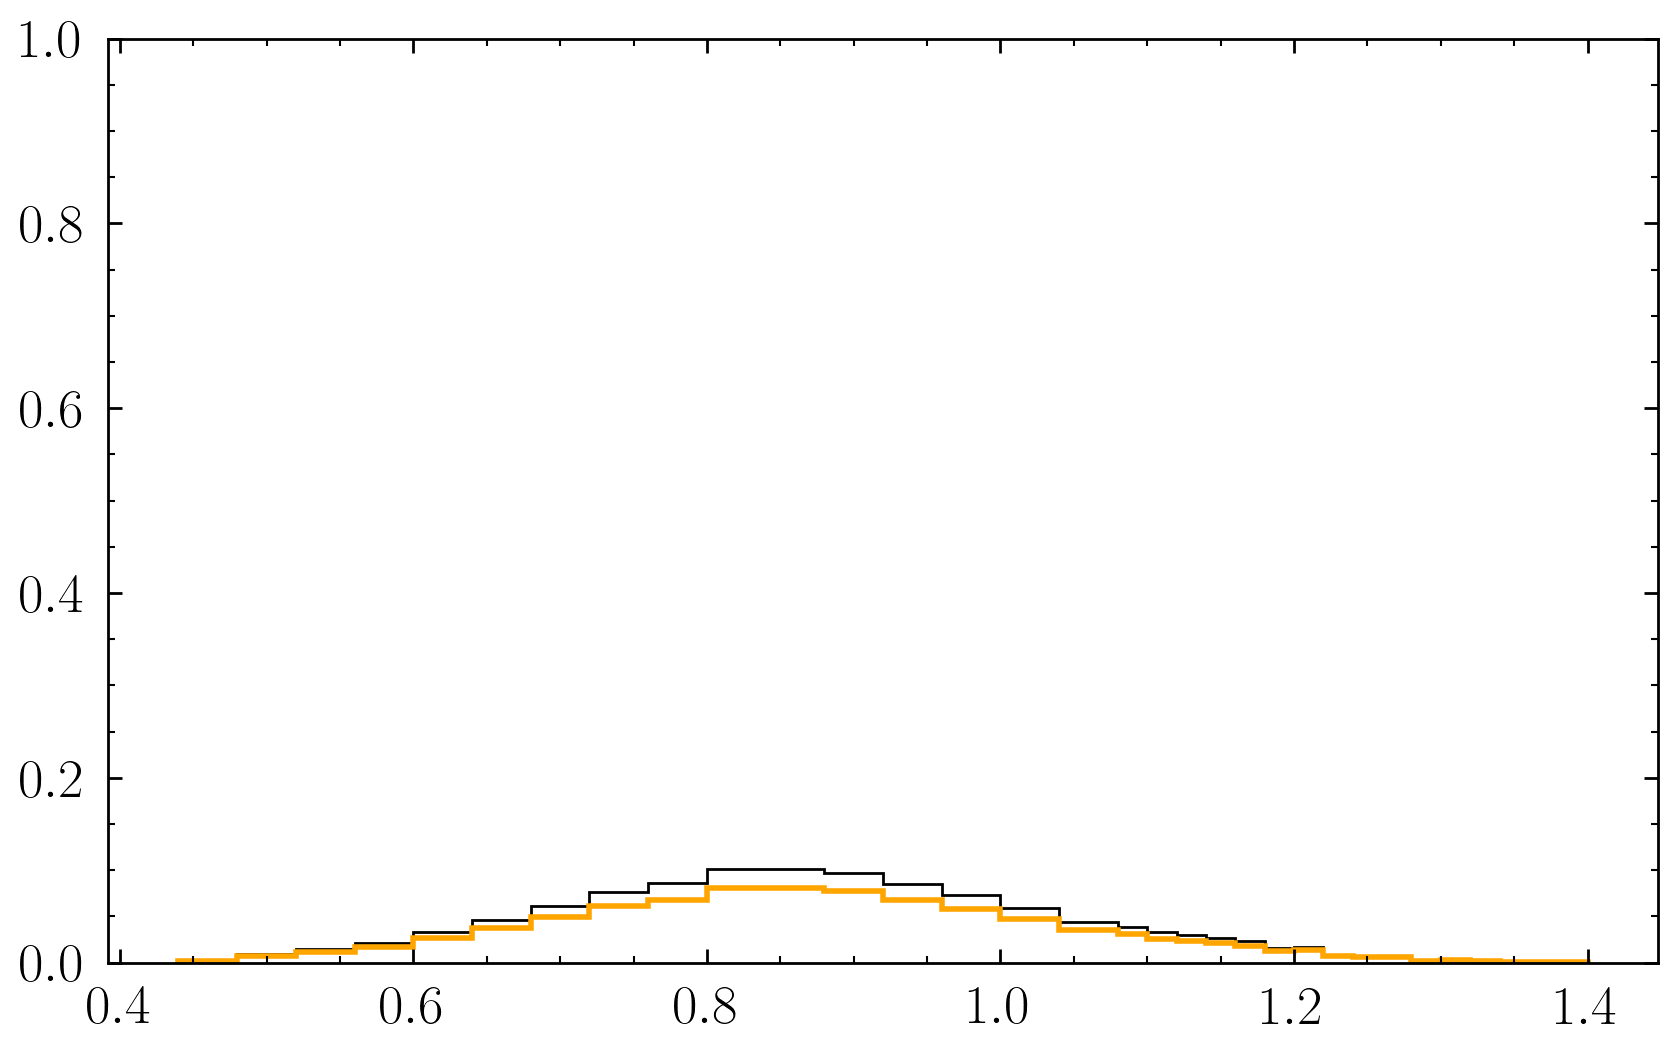

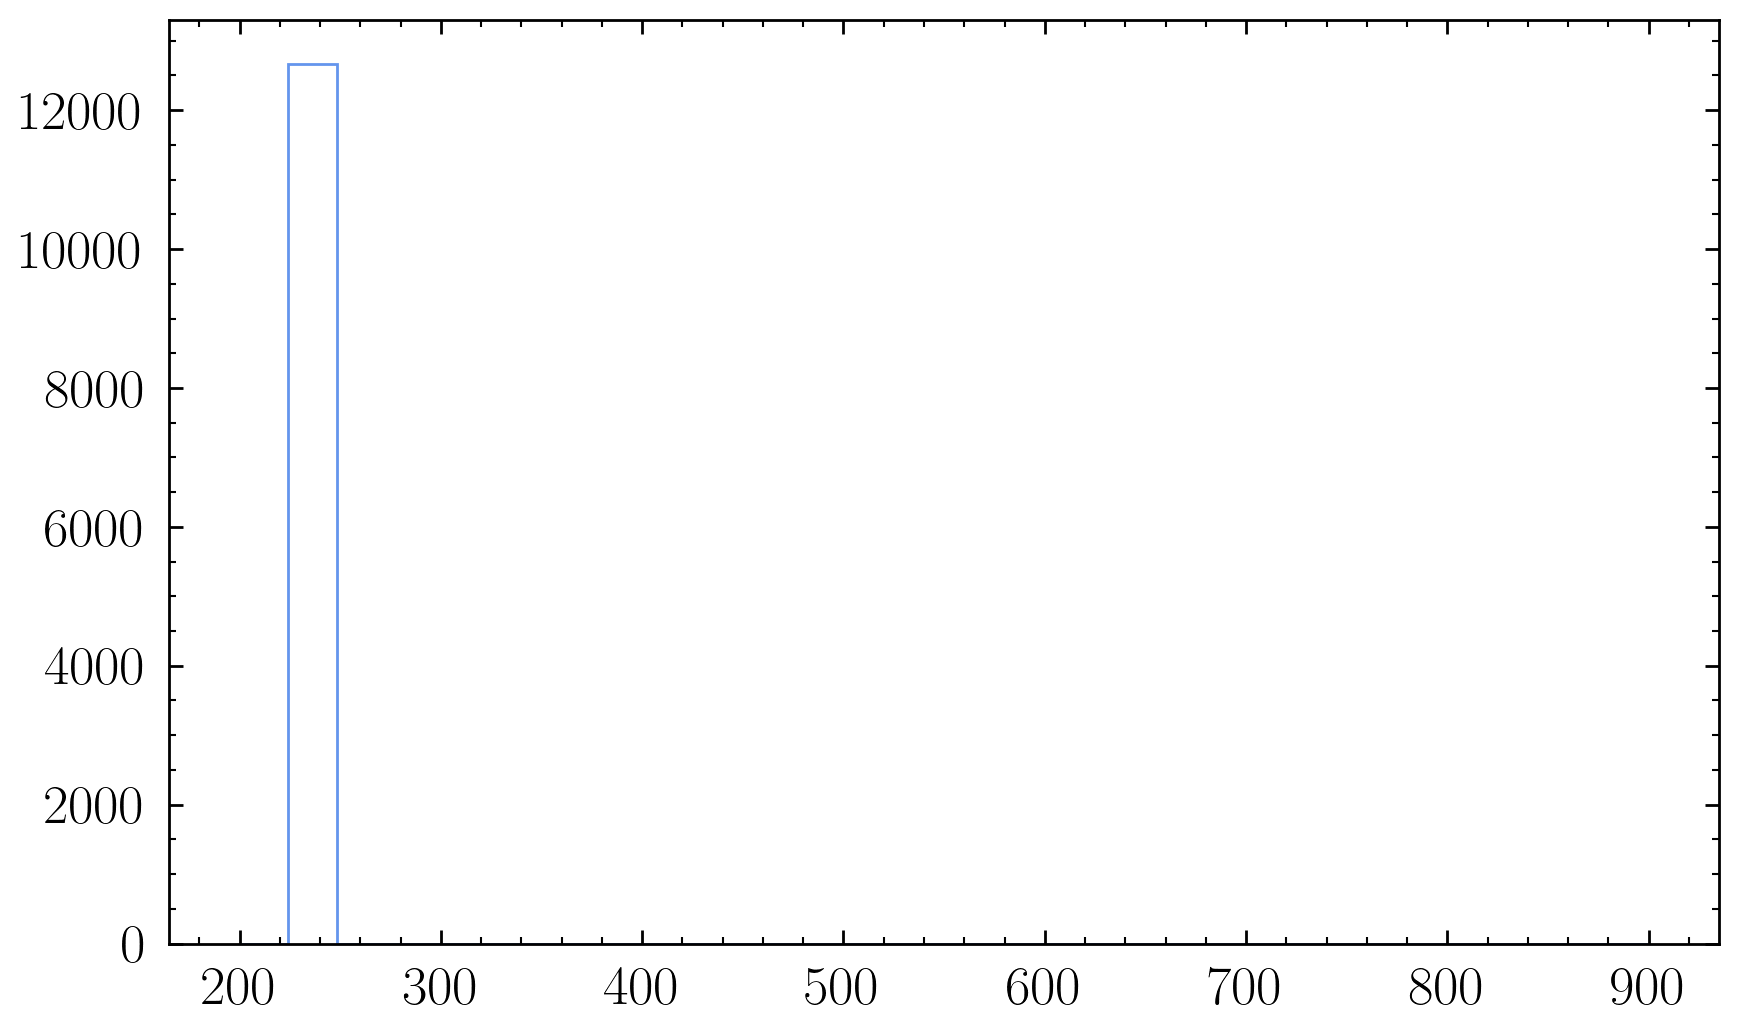

In [57]:
numbins = 50
omegalow = 100
omegahigh = 900

Q2_bins = np.linspace(0,1.4,30)
EQE_bins = np.linspace(.4,1.4,30)

dtheta = 1
angle = 37.5
wbins=np.linspace(200,900,30)

omega_nuc,cos12_nuc,Q2_nuc,leading_mom_an1,subleading_mom_an1,cospp1_2,cospp2_2,Emiss_pp3,Emiss_np3,EQE_nuc = get_double_diff_xsec_wgt('test_FG_full_1159_100000p00_2.out', angle, dtheta, wbins)
#omega_nuc,cos12_nuc_re,Q2_nuc_re,leading_mom_an1_re,subleading_mom_an1_re,cospp1_2_re,cospp2_2_re,Emiss_pp3_re,Emiss_np3_re,EQE_nuc_re = get_double_diff_xsec_wgt_re('test_FG_full_1159_100000p00_2.out', angle, dtheta, wbins)

#Q2_nuc,leading_mom_an1,leading_mom_re_an1,subleading_mom_an1,cospp1_2,cospp2_2,Emiss_pp3,Emiss_np3,EQE_nuc_SF = get_double_diff_xsec_wgt('test_FG_1159_q2min_0p1GeV2.out', angle, dtheta, wbins)
#Q2_nuc,leading_mom_an1,leading_mom_re_an1,subleading_mom_an1,cospp1_2,cospp2_2,Emiss_pp3,Emiss_np3,EQE_nuc_SF = get_double_diff_xsec_wgt('test_FG_1159_q2min_0p1GeV2.out', angle, dtheta, wbins)

#fig,ax = plt.subplots(1,1,figsize=(15,6))
#Q2_bin_centers = (Q2_bins[:-1] + Q2_bins[1:]) / 2
#ax.stairs(Q2_nuc,Q2_bins,color='black',label=r'$\Delta + \pi$')

fig,ax = plt.subplots(1,1,figsize=(10,6))
EQE_bin_centers = (EQE_bins[:-1] + EQE_bins[1:]) / 2
ax.stairs(EQE_nuc*1e-6,e4v_EQE_bins,color='black',label=r'$\Delta + \pi$')
ax.stairs((achilles_2p2h["EQE"]["qe"])/np.diff(e4v_EQE_bins)/1e6,e4v_EQE_bins,label=r'2p2h FG oset',color='orange',linewidth=2)

ax.set_ylim([0,1])
#ax.set_xlim([0.5,1.4])
wbins=np.linspace(200,900,30)
fig,ax = plt.subplots(1,1,figsize=(10,6))
ax.stairs(omega_nuc, wbins)


#ax.set_xlabel('$E_{QE}$ (GeV)')
#ax.set_ylabel(r'$\frac{d\sigma}{dE_{QE}} (\mu b \,\rm{GeV}^{-1})$')

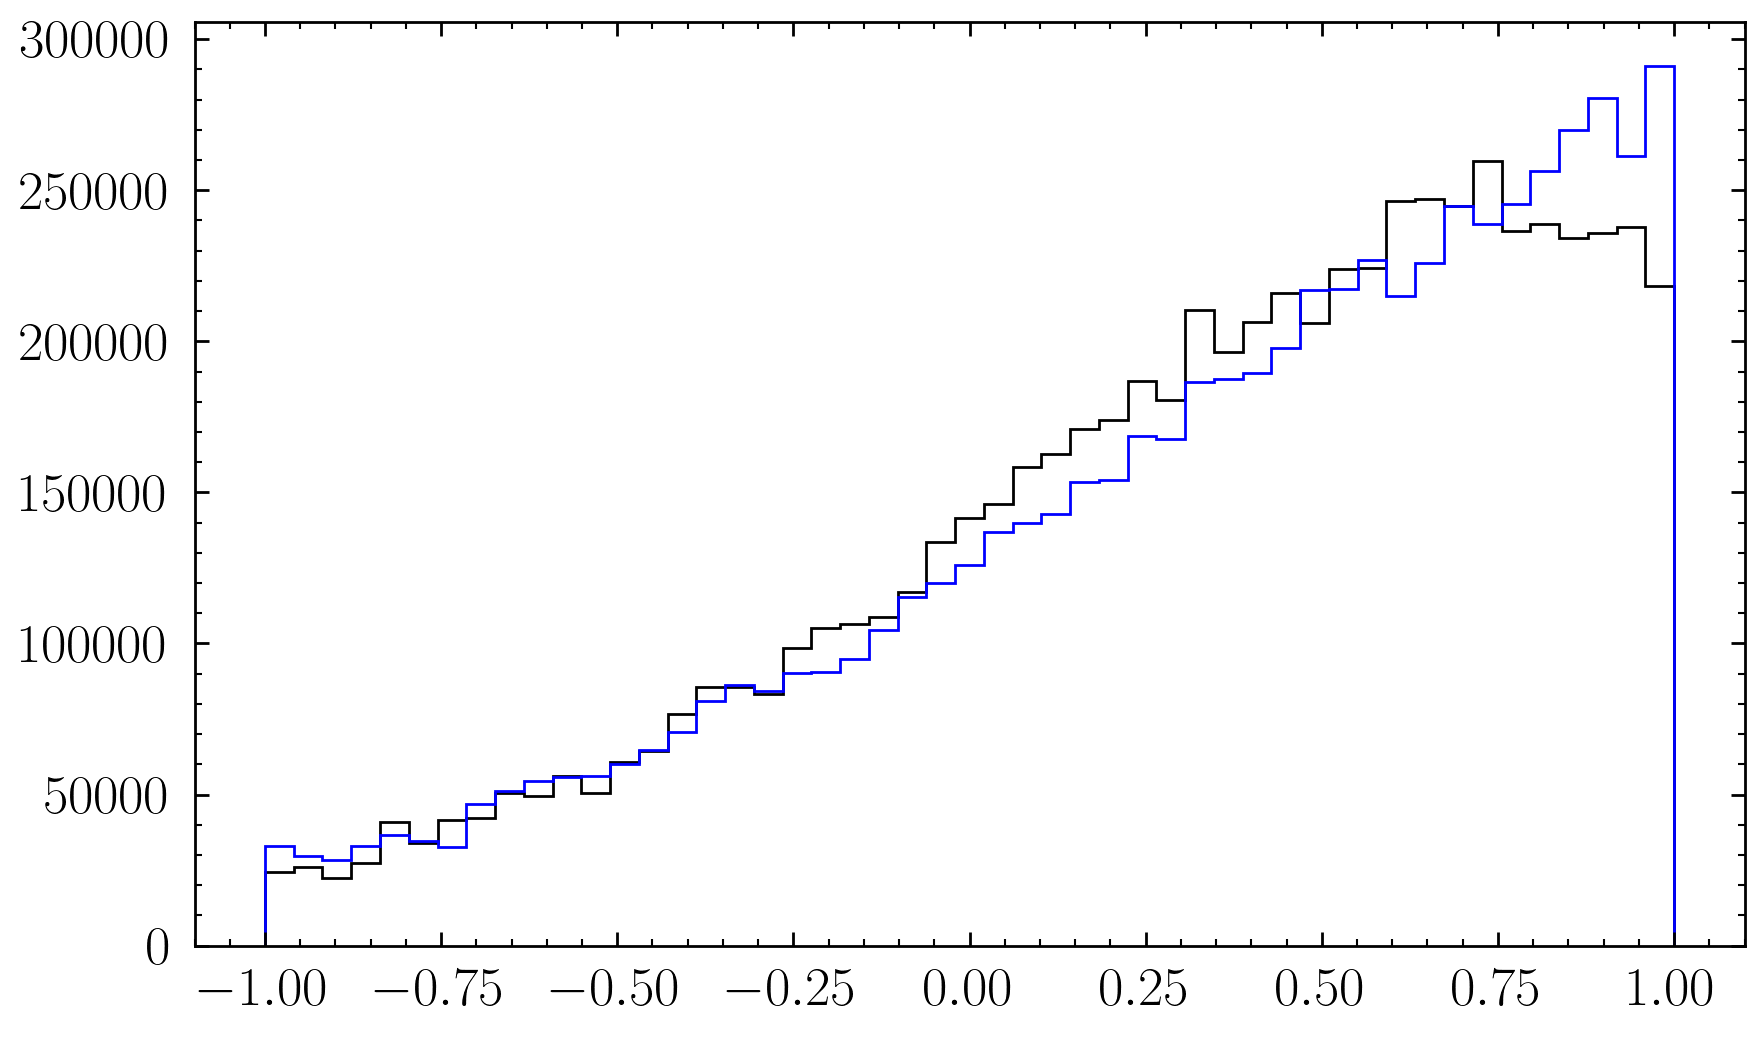

In [170]:
mybins_omega = np.ones(50)
mybins2 = np.linspace(-1.,1.,len(mybins_omega))
mybins_leadingmom = np.linspace(225.,1500.,len(mybins_omega))
#mybins_totalE = np.linspace(emin,3000,len(mybins_omega))
momentum_bins = np.linspace(225,1200,30)
emiss_bins = np.linspace(0,300,60)
init_momentum_bins = np.linspace(0,600,16)
init_momentum_bins_more = np.linspace(0,600,30)
Q2_bins = np.linspace(0,1.4,30)
EQE_bins = np.linspace(0.4,1.4,30)
EQE_bins_resampled = np.linspace(0.4,1.4,30)


fig,ax = plt.subplots(1,1,figsize=(10,6))
ax.stairs(cospp1_2,mybins2,color='black',label=r'$\Delta + \pi$')
ax.stairs(cospp1_2_re,mybins2,color='blue',label=r'$\Delta + \pi$')
#ax.set_ylim([0,1])
#ax.set_xlim([0.5,1.4])

In [4]:
def sample_p(kf, size=1):
    r = np.random.uniform(0, 1, size)
    return kf * r**(1/3)

def lorentz_boost(fourvec, beta):
    """
    fourvec: array_like (E, px, py, pz)
    beta: array_like (vx, vy, vz) with |beta| < 1
    returns: boosted fourvec (E', px', py', pz')
    """
    E = fourvec[0]
    p = np.array(fourvec[1:])
    beta = np.array(beta)
    beta2 = np.dot(beta, beta)
    if beta2 >= 1.0:
        raise ValueError("Beta squared >= 1!")
    gamma = 1.0/np.sqrt(1.0 - beta2)
    bp = np.dot(beta, p)
    E_prime = gamma * (E + bp)
    p_prime = p + ((gamma - 1)/beta2)*bp*beta + gamma*E*beta
    return np.array([E_prime, *p_prime])
    
def resample_2nuc(q,kf):
    moms = sample_p(kf,2)
    p1mag = moms[0]
    p2mag = moms[1]

    M2 = -1.
    while(M2 < 0):
        costheta1 = np.random.uniform(-1,1)
        sintheta1 = np.sqrt(1. - costheta1**2)
        phi1 = np.random.uniform(0,2*np.pi)
        
        costheta2 = np.random.uniform(-1,1)
        sintheta2 = np.sqrt(1. - costheta2**2)
        phi2 = np.random.uniform(0,2*np.pi)
    
        p1 = np.array([0,p1mag*sintheta1*np.cos(phi1),p1mag*sintheta1*np.sin(phi1), p1mag*costheta1])
        p2 = np.array([0,p2mag*sintheta2*np.cos(phi2),p2mag*sintheta2*np.sin(phi2), p2mag*costheta2])

        p1[0] = np.sqrt(xmn**2 + np.dot(p1[1:4],p1[1:4]))
        p2[0] = np.sqrt(xmn**2 + np.dot(p2[1:4],p2[1:4]))
        
        #print('p1 = ', p1)
        #print('p2 = ', p2)
        
        ptot = q + p1 + p2
        
        ptot_mag = np.sqrt(np.dot(ptot[1:4],ptot[1:4]))
        Etot = q[0] + p1[0] + p2[0]
        #print('Etot = ', Etot)

        #print('ptot = ', ptot)
        M2 = Etot**2 - ptot_mag**2 - 4.0*xmn**2

        #print('M = ', np.sqrt(M2))

        costhetacm = np.random.uniform(-1,1)
        sinthetacm = np.sqrt(1. - costhetacm**2)
        phicm = np.random.uniform(0,2*np.pi)

        Epp1_cm = 0.5*np.sqrt(Etot**2 - ptot_mag**2)
        pp1mag_cm = np.sqrt(Epp1_cm**2 - xmn**2)
        #print('pp1 cm = ', pp1mag_cm)
        pp1_cm = np.array([pp1mag_cm*sinthetacm*np.cos(phicm), pp1mag_cm*sinthetacm*np.sin(phicm),pp1mag_cm*costhetacm])
        pp2_cm = -pp1_cm

        #print('pp1 cm = ', pp1_cm)
        #print('pp2 cm = ', pp2_cm)
        #print('ptot[1:4] = ', ptot[1:4])
        vcm = ptot[1:4]/Etot
        #print('vcm = ', vcm)
        vcm_mag = np.sqrt(np.dot(vcm,vcm))
        #print('vcm_mag = ', vcm_mag)
        uhatcm = vcm/vcm_mag
        gammacm = 1.0/np.sqrt(1. - vcm_mag**2)
        
        pp1 = (gammacm*vcm_mag*Epp1_cm + (gammacm - 1.0)*np.dot(pp1_cm,uhatcm))*uhatcm + pp1_cm
        pp2 = (gammacm*vcm_mag*Epp1_cm + (gammacm - 1.0)*np.dot(pp2_cm,uhatcm))*uhatcm + pp2_cm

        beta = vcm
        pp1 = lorentz_boost([Epp1_cm, *pp1_cm], beta)
        pp2 = lorentz_boost([Epp1_cm, *pp2_cm], beta)

        pp1_mag = np.sqrt(np.dot(pp1,pp1))
        pp2_mag = np.sqrt(np.dot(pp2,pp2))

        #print('|pp1| = ', pp1_mag)
        #print('|pp2| = ', pp2_mag)
        
        Epp1 = np.sqrt(pp1_mag**2 + xmn**2)
        Epp2 = np.sqrt(pp2_mag**2 + xmn**2)

        if (pp1_mag < kf or pp2_mag < kf):
            M2 = -1.
        #print('pp1 = ', [Epp1,pp1[0],pp1[1],pp1[2]])
        #print('pp2 = ', [Epp2,pp2[0],pp2[1],pp2[2]])
        #print('Energy conservation check --------')
        #print(q + p1 + p2, np.array([Epp1,pp1[0],pp1[1],pp1[2]]) + np.array([Epp2,pp2[0],pp2[1],pp2[2]]))
        return np.array(pp1),np.array(pp2)


In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pyhepmc
import math
import pandas as pd

In [38]:
#Takes in a particle and returns its 4-momentum
def get_4vec(particle):
    return np.array([particle.momentum.e,particle.momentum.px,particle.momentum.py,particle.momentum.pz])

#Takes in a particle and returns the magnitude of its 3-momentum
def mom(particle):
    return np.sqrt(particle.momentum.e**2 - particle.momentum.m()**2)

#Returns cosine of angle between two 3 vectors
def angle_between(p1,p2):
    return np.dot(p1,p2)/(np.sqrt(np.dot(p1,p1))*np.sqrt(np.dot(p2,p2)))

#Returns all outgoing particles with PID in the list of ids
def outgoing_particles(event, ids):
    particles =  [p for p in event.particles for id in ids if np.abs(p.pid)==id and p.status==1 ]
    return particles

#Returns incoming particle with specific PID (there should only be one)
def incoming_particle(event, pid):
    particles =  [p for p in event.particles if np.abs(p.pid)==pid and p.status==2]
    return particles[0]

#longitudinal projection of momentum p1 onto p2
def long_proj(p1,p2):
    p1dotp2 = np.dot(p1,p2)
    p2sq = np.dot(p2,p2)
    return (p1dotp2/p2sq)*p2
    
#transverse projection of momentum p1 onto p2
def trans_proj(p1,p2):
    return p1 - long_proj(p1,p2)

def electron_accepted(probe_p3,part_p3):
    theta = np.arccos(angle_between(probe_p3,part_p3))*180/np.pi
    p = np.sqrt(part_p3[0]**2 + part_p3[1]**2 + part_p3[2]**2)
    
    if (theta < 17. + 7./(p/1000.) or theta > 45.):
        return False

    if p < 400:
        return False
    
    return True

def has_a_pion(probe_p3,part):
    p = mom(part)
    part_p3 = [part.momentum.px, part.momentum.py, part.momentum.pz]
    theta = np.arccos(angle_between(probe_p3,part_p3))*180/np.pi
    
    if part.pid == -211:
        if p < 150.:
            return False
        if (theta < 17. + 4./(p/1000.)):
            return False
        
    if part.pid == 211:
        if p < 150.:
            return False
        if theta < 12.:
            return False

    if part.pid == 111:
        return True
        
    return True

def has_a_photon(probe_p3,part):
    p = mom(part)
    part_p3 = [part.momentum.px, part.momentum.py, part.momentum.pz]
    theta = np.arccos(angle_between(probe_p3,part_p3))*180/np.pi
    
    if p < 300:
        return False
    if theta < 8:
        return False
    if theta > 45: 
        return False
    
    return True

def has_a_proton(probe_p3,part):
    p = mom(part)
    part_p3 = [part.momentum.px, part.momentum.py, part.momentum.pz]
    theta = np.arccos(angle_between(probe_p3,part_p3))*180/np.pi
    
    if p < 300:
        return False
    if theta < 12:
        return False
    
    return True  

In [46]:
mp = 938.272
mn = 939.565
mxn = (mp + mn)/2.
eps = 21.0

conversion = 1e-6 #results in nb

#incoming lepton pid, outgoing lepton PID, achilles file name, number of bins in your histograms, lower bound on scattering angle (deg), upper bound on scattering angle (deg)
def analysis(inlep_pid,outlep_pid,file,number_of_bins):
    xsec = 0
    events = 0
    
    #Kinematics
    probep4 = []
    leptonp4 = []

    incl_bins = np.linspace(200,700,20)
    
    #Observables
    #3 arrays for 3 interactions right now
    EQE_qe = np.zeros(len(e4v_EQE_bins) -1)
    EQE_res = np.zeros(len(e4v_EQE_bins) -1)
    
    #ECAL_qe = np.zeros(len(e4v_ECAL_bins) -1)
    #ECAL_res = np.zeros(len(e4v_ECAL_bins) -1)

    #PT_qe = np.zeros(len(e4v_PT_bins) -1)
    #PT_res = np.zeros(len(e4v_PT_bins) -1)

    incl = np.zeros(len(incl_bins) -1)
    
    #Sum of all the weights
    sum_of_weights = 0
    
    with pyhepmc.open(file) as f:
        for event in f:
            
            events += 1
            
            qe = False
            intf = False
            pi = False
            has_pion = False
            has_photon = False
            good_protons = 0
            Onep0pi = False
            
            #Figure out which process
            process_id = event.attributes['signal_process_id'].astype(int)
            if(process_id >= 200 and process_id <= 300):
                qe = True 
            elif(process_id >= 400 and process_id <= 500):
                pi = True
            elif(process_id >= 700 and process_id <= 800):
                intf = True
            qe = True
            #Grab the incoming and outgoing lepton as well as outgoing nucleons
            probe = incoming_particle(event,inlep_pid)
            leptons = outgoing_particles(event,[outlep_pid])
            
            #Get their 4-vectors
            probe_p4 = get_4vec(probe)
            lepton_p4 = get_4vec(leptons[0])
            
            #Get the latest estimate of the total cross section
            xsec =  event.cross_section.xsec()
            #print('xsec = ', xsec)
            #print('weight = ', event.weights[0])
            #break
            
            #Get 3 momenta 
            probe_3 = np.array([probe_p4[1],probe_p4[2], probe_p4[3]])
            lep_3 = np.array([lepton_p4[1], lepton_p4[2], lepton_p4[3]])
            
            #Smear lepton
            #elec_res = np.random.normal(1.0, .015)
            elec_res = 1.0
            lep_3 = [lep_3[0]*elec_res, lep_3[1]*elec_res, lep_3[2]*elec_res]
            El = np.sqrt(np.dot(lep_3,lep_3))
            lepton_p4 = [El,lep_3[0],lep_3[1],lep_3[2]]
            
            #Four momentum transfer
            q = probe_p4 - lepton_p4 
            Q2 = np.abs(q[0]**2 - q[1]**2 - q[2]**2 - q[3]**2)/(1000**2)
            Q4 = Q2**2

            omega = q[0]
            
            #Store the event weight
            #event_weight = 1.*Q4#event.weights[0]*Q4
            event_weight = event.weights[0]*Q4
            #Add it to the total weights
            sum_of_weights += event_weight/Q4  
            
            #Cut on Q2
            if Q2 < .1:
                continue
            
            if electron_accepted(probe_3,lep_3) == False:
                continue    
        
            lepton_pT = trans_proj(lep_3,probe_3)
        
            proton_E = 0
            proton_pT = [0,0,0] 
            proton_3 = [0,0,0]
            
            for p in event.particles:
                if p.status==1:
                    if (p.pid == 211 or p.pid == -211 or p.pid == 111): 
                        has_pion = has_a_pion(probe_3,p)
                    if (p.pid == 22):
                        has_photon = has_a_photon(probe_3,p)
                    if (p.pid == 2212):
                        if(has_a_proton(probe_3,p)):
                            good_protons += 1
                            #proton_res = np.random.normal(1.0, .03)
                            proton_res = 1.0
                            proton_3 = np.array([p.momentum.px*proton_res,p.momentum.py*proton_res,p.momentum.pz*proton_res])
                            proton_E = np.sqrt(np.dot(proton_3,proton_3) + mn*mn)
                            proton_pT = trans_proj(proton_3,probe_3)
            
            if has_pion == True:
                continue
                
            if has_photon == True:
                continue
                    
            costhetal = angle_between(probe_3,lep_3)

            #if (thetal > 38.5 or thetal < 36.5):
            #    continue
            
            EQE = (mxn*eps + mxn*El)/(mxn - El + El*costhetal)/1000.
            ECal = 0
            pT = 0
            if(good_protons == 1):
                Onep0pi = True
                ECal = (El + proton_E - mn + eps)/1000.
                #Compute lepton and nucleon pT and pL
                pT_3 = proton_pT + lepton_pT
                pT = np.sqrt(np.dot(pT_3,pT_3))/1000.

            # Fill histograms
            #idxincl = np.searchsorted(incl_bins, omega, side='left')
            #if idxincl > len(incl_bins)-1:
            #    continue
            idx1 = np.searchsorted(e4v_EQE_bins, EQE, side='left')
            if idx1 > len(e4v_EQE_bins)-1:
                continue
            #idx2 = np.searchsorted(e4v_ECAL_bins, ECal, side='left')
            #if idx2 > len(e4v_ECAL_bins)-1:
                continue
            #idx3 = np.searchsorted(e4v_PT_bins, pT, side='left')
            #if idx3 > len(e4v_PT_bins)-1:
                continue

            
            #incl[idxincl-1] += event_weight
            #fill arrays with observables for each channel
            if qe == True:
                EQE_qe[idx1-1] += event_weight
                #if Onep0pi == True:
                    #ECAL_qe[idx2-1] += event_weight
                    #PT_qe[idx3-1] += event_weight
                
            if pi == True:
                EQE_res[idx1-1] += event_weight
                #if Onep0pi == True:
                    #ECAL_res[idx2-1] += event_weight
                    #PT_res[idx3-1] += event_weight


    dcos = np.cos(36.5*np.pi/180) - np.cos(38.5*np.pi/180)
    dphi = 2*np.pi

    EQE_hist = [[],[],[]]
    ECAL_hist = [[],[],[]]
    PT_hist = [[],[],[]]
    EQE_hist[0] = EQE_qe *xsec * conversion/sum_of_weights
    EQE_hist[2] = EQE_res *xsec * conversion/sum_of_weights
    #ECAL_hist[0] = ECAL_qe *xsec * conversion/sum_of_weights
    #ECAL_hist[2] = ECAL_res *xsec * conversion/sum_of_weights
    #PT_hist[0] = PT_qe *xsec * conversion/sum_of_weights
    #PT_hist[2] = PT_res *xsec * conversion/sum_of_weights

    incl_hist = incl * xsec * conversion/sum_of_weights/dcos/dphi

    
    #EQE_hist[0] = EQE_qe * conversion/sum_of_weights
    #EQE_hist[2] = EQE_res * conversion/sum_of_weights
    #ECAL_hist[0] = ECAL_qe * conversion/sum_of_weights
    #ECAL_hist[2] = ECAL_res * conversion/sum_of_weights
    #PT_hist[0] = PT_qe * conversion/sum_of_weights
    #PT_hist[2] = PT_res * conversion/sum_of_weights
    
    hists = {}
    #hists["EQE"] = {"qe":EQE_hist[0][0], "intf":EQE_hist[1][0], "res":EQE_hist[2][0], "bins":EQE_hist[0][1]}
    hists["EQE"] = {"qe":EQE_hist[0], "intf":EQE_hist[1], "res":EQE_hist[2]}
    #hists["ECAL"] = {"qe":ECAL_hist[0], "intf":ECAL_hist[1], "res":ECAL_hist[2]}
    #hists["PT"] = {"qe":PT_hist[0], "intf":PT_hist[1], "res":PT_hist[2]}
    hists["incl"] = incl_hist
   
    print('Number of Events: ', events, ', Total cross section: ', xsec, ' barns')
    return hists

In [40]:
e4v_EQE_bins = np.array([0.44, 0.48, 0.52, 0.56, 0.60, 0.64, 0.68, 0.72, 0.76, 0.80, 
0.84, 0.88, 0.92, 0.96, 1.00, 1.04, 1.08, 1.10, 1.12, 1.14, 
1.16, 1.18, 1.20, 1.22, 1.24, 1.26, 1.28, 1.30, 1.32, 1.34, 
1.36, 1.38, 1.40])
e4v_EQE_xsec = [0.007, 0.042, 0.084, 0.130, 0.171, 0.208, 0.241, 0.271, 0.300, 0.324, 
0.336, 0.341, 0.340, 0.352, 0.391, 0.471, 0.546, 0.613, 0.673, 0.723, 
0.761, 0.748, 0.708, 0.641, 0.568, 0.470, 0.364, 0.307, 0.267, 0.238, 
0.211, 0.195]
e4v_EQE_xsec_err = [0.000, 0.003, 0.005, 0.008, 0.011, 0.013, 0.016, 0.018, 0.019, 0.021, 
0.021, 0.022, 0.022, 0.023, 0.025, 0.030, 0.035, 0.039, 0.043, 0.046, 
0.048, 0.047, 0.045, 0.041, 0.036, 0.030, 0.023, 0.020, 0.021, 0.026, 
0.028, 0.034]

EQE_bin_centers = [(e4v_EQE_bins[i] + e4v_EQE_bins[i+1]) / 2 for i in range(len(e4v_EQE_bins)-1)]

In [47]:
achilles_2p2h = analysis(11,11,'/Users/noah/Desktop/Achilles.nosync/build_dev/test.hepmc',25)


Number of Events:  100000 , Total cross section:  1275957460000.0  barns
